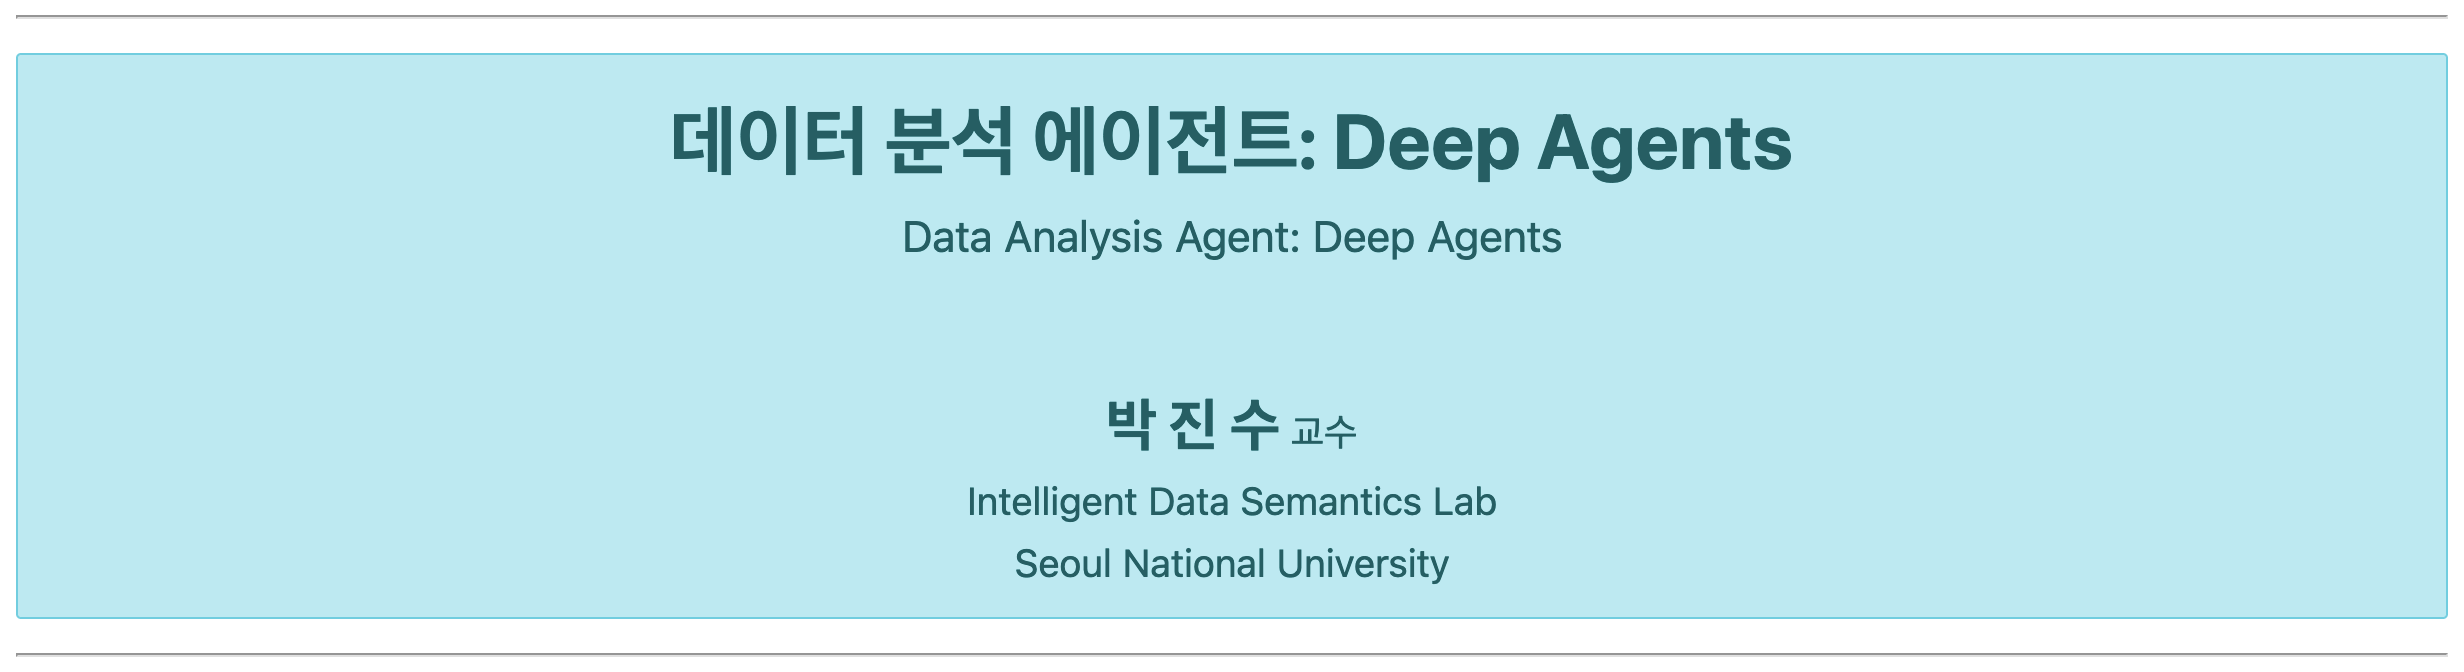

- - -    

- 본 자료는 강의를 위한 목적으로 LangChain이 제공하는 자료에 기반하여 제작했습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#백엔드-설정" data-toc-modified-id="백엔드-설정-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>백엔드 설정</a></span></li><li><span><a href="#샘플-데이터-업로드" data-toc-modified-id="샘플-데이터-업로드-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>샘플 데이터 업로드</a></span></li><li><span><a href="#시스템-프롬프트" data-toc-modified-id="시스템-프롬프트-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>시스템 프롬프트</a></span></li><li><span><a href="#모델-초기화" data-toc-modified-id="모델-초기화-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>모델 초기화</a></span></li><li><span><a href="#에이전트-구성" data-toc-modified-id="에이전트-구성-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>에이전트 구성</a></span></li><li><span><a href="#도우미-함수-가져오기" data-toc-modified-id="도우미-함수-가져오기-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>도우미 함수 가져오기</a></span></li><li><span><a href="#실행" data-toc-modified-id="실행-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>실행</a></span></li><li><span><a href="#Lab:-외부-검색-기반-해석-보강-리포트-작성하기" data-toc-modified-id="Lab:-외부-검색-기반-해석-보강-리포트-작성하기-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Lab: 외부 검색 기반 해석 보강 리포트 작성하기</a></span></li></ul></div>

# 패키지 설치 및 API 설정

In [ ]:
!python -m pip install -qU python-dotenv gdown rich 'deepagents>=0.5' langchain # YOUR LLM package HERE(e.g., openai anthropic google-genai groq mistralai ollama)
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

In [ ]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

# 백엔드 설정

In [4]:
from pathlib import Path
from deepagents.backends import LocalShellBackend

# 에이전트 (백엔드)가 데이터 및 결과를 두는 폴더. 상대 경로로 통일 (업로드, 도구, 실행 셀에서 사용)
WORKSPACE = 'tips'

# Windows 에서는 env 생략 권장. 예: LocalShellBackend(root_dir='.', virtual_mode=False)
backend = LocalShellBackend(
    root_dir='.', 
    env={'PATH': '/usr/bin:/bin'}, # Windows 에서는 env 생략 권장
    virtual_mode=False
)

# 샘플 데이터 업로드

In [ ]:
import gdown
!gdown 1REyWa4twimJykFmCkTq4ICZVOt_hmc1H -O tips.csv

In [3]:
# --- 샘플 데이터: 로컬에 있는 CSV를 프로젝트 안으로 복사하는 이유
# 데이터 파일은 지금 프로젝트 밖(예: 다른 폴더) 절대 경로에 있다. 에이전트와 생성 스크립트는
# root_dir(.) 아래 상대 경로만 쓰는 것이 좋으므로, 이 셀에서 해당 파일을 읽어
# 프로젝트 내 tips/tips.csv 로 한 번 복사(업로드)해 둔다. 그러면 에이전트는
# read_file('tips/tips.csv')로 읽고, 생성 스크립트도 pandas.read_csv('tips/tips.csv') 등
# 상대 경로로 작성할 수 있다.
DATA_PATH = 'tips.csv'  # 로컬에서 읽을 CSV 경로
with open(DATA_PATH, mode='rb') as file:
    csv_bytes = file.read()
# upload_files 는 상위 폴더가 없으면 자동으로 생성한다. 
backend.upload_files([(f'{WORKSPACE}/tips.csv', csv_bytes)])

[FileUploadResponse(path='tips/tips.csv', error=None)]

# 시스템 프롬프트

In [7]:
INSTRUCTION = '''Respond in the same language as the user’s message.
For example, if the user asks in English, respond in English.
If the user asks in Korean, respond in Korean.

Please respond using plain text only. 
Do not use any Markdown formatting.

When the user specifies an output folder for generated files (plots, reports, etc.), 
save all such files there using relative paths. 
If no folder is specified, use the current working directory.

In any Python script you write: use ONLY relative paths (e.g. tips, ./tips). 
Never hardcode absolute paths (e.g. /data/tips) or user-specific paths (e.g. /Users/username/...). 
Assume the script runs with the project root as current working directory, so paths work on any machine.
'''

# 모델 초기화 

In [8]:
# --- 모델 초기화
from langchain.chat_models import init_chat_model


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 에이전트 구성

In [9]:
from langgraph.checkpoint.memory import InMemorySaver
from deepagents import create_deep_agent

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

memory = 
agent  = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

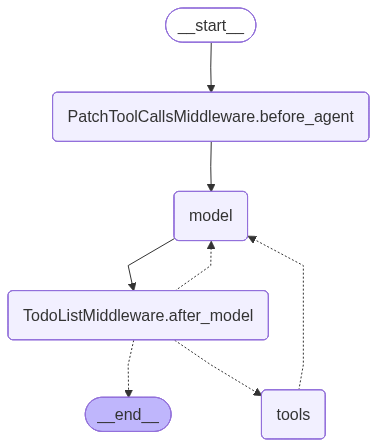

In [9]:
agent

# 도우미 함수 가져오기


In [ ]:
# --- utils.py 다운로드
!gdown 1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi -O utils.py

# 실행

In [7]:
import uuid
from langchain.messages import HumanMessage
from rich.console import Console
from rich.markdown import Markdown
from utils import extract_text


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

config = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# --- WORKSPACE는 백엔드 셀에서 정의했다. tips 폴더는 업로드 셀의 upload_files에서 자동 생성했다.
user_message = f'''{WORKSPACE}/tips.csv를 분석하십시오.
총 지불 금액(total_bill), 팁(tip), 성별(sex), 요일(day), 시간대(time) 등을 활용한 탐색적 데이터 분석을 수행하십시오.
팁 비율(tip/total_bill)을 계산하고, 요일·시간대별 평균 팁과 매출을 비교하십시오. 적절한 통계 요약과 인사이트를 도출하십시오.
결과를 시각화하십시오 (예: 팁 비율 분포, 요일별 평균 팁, total_bill과 tip 산점도 등).

생성한 모든 파일(플롯, 분석 리포트 등)은 현재 작업 디렉토리의 '{WORKSPACE}' 폴더에 저장하십시오. 해당 폴더가 없으면 먼저 생성한 뒤 저장하십시오.
분석 내용과 저장한 파일 경로를 포함해 최종 결과를 요약하십시오.
'''

result = agent.invoke(
    input={'messages': [HumanMessage(user_message)]},
    config=config
)
console = Console()
console.print(Markdown(extract_text(result)))

분석이 완료되었습니다. 아래는 전체 결과 요약입니다.                                                                

데이터 개요                                                                                                        

244건의 레스토랑 결제 데이터. 컬럼: total_bill, tip, sex, smoker, day, time, size 파생 변수 tip_ratio(= tip /      
total_bill) 를 추가 계산.                                                                                          

기초 통계 요약                                                                                                     

항목 / 평균 / 중앙값 / 최솟값 / 최댓값 total_bill : $19.79 / $17.80 / $3.07 / $50.81 tip        : $3.00  / $2.90  /
$1.00 / $10.00 tip_ratio  : 16.1%  / 15.5%  / 3.6%  / 71.0%                                                        

팁 비율은 오른쪽 꼬리 분포(극단적 고팁 이상치 존재).                                                               

요일·시간대별 비교                                                                                                 

요일별: 일요일(Sun)이 평균 팁 $3.26, 평균 매출 $21.41로 모두 최고. 금요일은 팁 비율 16.99%로 최고지만 표본이       
19건으로 가장 적어 해석 주의.                                                                                      

시간대별: Dinner가 절대 금액(평균 $3.10 팁, $20.80 매출)이 더 높고, Lunch는 팁 비율(16.4%)이 소폭 더 높음.         

성별 비교                                                                                                          

남성이 절대 팁 금액($3.09)은 더 많지만, 팁 비율은 여성(16.65%)이 남성(15.77%)보다 높음.                            

상관 분석                                                                                                          

total_bill ↔ tip 상관계수 0.676 - 결제 금액이 클수록 팁 증가. total_bill ↔ size 상관계수 0.598 - 인원이 많을수록   
결제액도 증가.                                                                                                     

저장된 파일 (tips/ 폴더)                                                                                           

tips/fig1_tip_ratio_distribution.png  — 팁 비율 히스토그램 + 박스플롯 tips/fig2_day_avg_tip_bill.png        —      
요일별 평균 팁 & 매출 막대그래프 tips/fig3_scatter_bill_tip.png        — total_bill vs tip 산점도 (성별·시간대 색상
구분, 추세선 포함) tips/fig4_tip_ratio_by_day_time.png   — 요일·시간대별 팁 비율 박스플롯                          
tips/fig5_sex_smoker_time_analysis.png — 성별·흡연여부 팁 비율 + 시간대 매출 파이차트                              
tips/fig6_heatmap_tip_ratio.png       — 요일 × 시간대 팁 비율 히트맵 tips/analyze_tips.py                  — 분석  
소스 코드 tips/analysis_report.txt              — 텍스트 분석 리포트

In [8]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

tips/tips.csv를 분석하십시오.
총 지불 금액(total_bill), 팁(tip), 성별(sex), 요일(day), 시간대(time) 등을 활용한 탐색적 데이터 분석을 수행하십시오.
팁 비율(tip/total_bill)을 계산하고, 요일·시간대별 평균 팁과 매출을 비교하십시오. 적절한 통계 요약과 인사이트를 도출하십시오.
결과를 시각화하십시오 (예: 팁 비율 분포, 요일별 평균 팁, total_bill과 tip 산점도 등).

생성한 모든 파일(플롯, 분석 리포트 등)은 현재 작업 디렉토리의 'tips' 폴더에 저장하십시오. 해당 폴더가 없으면 먼저 생성한 뒤 저장하십시오.
분석 내용과 저장한 파일 경로를 포함해 최종 결과를 요약하십시오.

================================== Ai Message ==================================
Name: Data-Analyst

[{'id': 'toolu_013wfup8tvmaxXKhAD9gnui4', 'caller': {'type': 'direct'}, 'input': {'todos': [{'content': 'tips/tips.csv 파일 읽기 및 구조 파악', 'status': 'in_progress'}, {'content': '탐색적 데이터 분석(EDA) 및 통계 요약 수행', 'status': 'pending'}, {'content': '시각화 플롯 생성 및 tips 폴더에 저장', 'status': 'pending'}, {'content': '분석 리포트 작성 및 저장', 'status': 'pending'}, {'content': '최종 결과 요약 제공', 'status': 'pending'}]}, 'name': 'write_todos', 'type': 'tool_use'}]
Tool Calls:
  wr

# Lab: 외부 검색 기반 해석 보강 리포트 작성하기

- - -
**목표** 
- `tips.csv` 내부 분석 결과를 기반으로 리포트를 작성하고, 외부 검색으로 확보한 근거를 결합해 해석을 보강한다.  
- 최종 리포트에는 내부 데이터 결론과 외부 근거의 연결 관계를 명확히 제시한다.

**요구사항**
1. 기존 분석 흐름은 유지하되, 외부 검색 도구(또는 동등한 기능의 커스텀 도구) **1**개를 추가한다.
2. 외부 검색은 최소 **2**회 수행하고, 최종 리포트에 최소 **2**개 출처(URL 또는 문서 링크)를 포함한다.
3. 최종 리포트는 아래 **3**개 구역을 모두 포함해야 한다.
    + (1) 내부 데이터 기반 결론
    + (2) 외부 근거 요약
    + (3) 최종 해석
4. 내부 데이터 결론과 외부 근거가 충돌하면, 충돌 원인과 신뢰 가능한 최종 판단 기준을 명시한다.
5. 생성한 리포트 파일 경로와 사용한 검색 출처 목록을 최종 응답에 함께 출력한다.

**최소 테스트 질문**: 다음 질문들은 반드시 테스트한다.
1. **'data/tips/tips.csv를 분석하고, 요일 및 시간대별 팁 비율 차이를 외부 근거로 보강한 리포트를 작성하세요.'**
2. **'data/tips/tips.csv를 분석하고, 성별 및 흡연 여부에 따른 팁 패턴을 외부 검색 근거와 함께 해석하세요.'**

**제출 안내**  
- 제출 파일은 `.ipynb` 노트북 파일이다.
- 기존 실습 코드 아래에 과제 코드를 추가하여 제출한다.
- 코드를 모르는 사람도 이해할 수 있도록 코드에 친절하고 상세한 주석을 포함한다.

<details>
<summary><b>클릭하여 💡힌트 보기</b></summary>

- 외부 검색은 수치 검증용이 아니라 해석 보강용으로 사용하면 안정적이다.
- 리포트 본문에 출처를 본문 인용 형태(예: [출처1], [출처2])로 연결하면 가독성이 높다.
- 검색 실패 또는 결과 부족 상황을 대비해 폴백 문구(예: '외부 근거 제한')를 준비하면 좋다.
- 최종 결론은 '내부 데이터 우선 + 외부 맥락 보강' 원칙으로 정리하면 일관성이 높다.

</details>

- - -

In [ ]:
# YOUR CODE HERE

**Example Output**

```
--- 테스트 질문 1 ---

리포트가 저장되었습니다. 아래는 최종 결과 요약입니다.                                                              

리포트 저장 경로                                                                                                   

tips/report_augmented_1.md   

리포트 3단 구성 요약                                                                                               

 1 내부 데이터 분석 결과                                                                                           

총 244건, 전체 평균 팁 비율 16.08% (중앙값 15.48%).                                                                

요일별 팁 비율 순위: 금(16.99%) > 일(16.69%) > 목(16.13%) > 토(15.32%)                                             

 • 토요일이 4개 요일 중 가장 낮고, 일요일은 표준편차(8.47%)가 가장 커 팁 패턴의 이질성이 크다.                     

시간대별: 점심(16.41%) > 저녁(15.95%)                                                                              

 • 저녁의 표준편차(6.75%)가 점심(4.02%)보다 훨씬 크다.                                                             

교차 분석 하이라이트: 금요일 점심(18.88%)이 세그먼트 최고치, 토요일 저녁(15.32%)이 최저. 파티 규모 효과:           
1인(21.73%) → 5인(14.15%)으로 규모 증가 시 팁 비율 뚜렷하게 감소.                                                  

 2 외부 근거 요약 (사용된 출처 URL)                                                                                

 • Eater (CAKE POS 데이터, 2017): 일요일 오전 팁이 최대 20%로 가장 높음                                            
   https://www.eater.com/2017/1/24/14365152/best-tips-servers-sunday                                               
 • Wall Street Journal (6,800만 건 신용카드 분석, 2024): 주말 팁이 평일 대비 최대 1%p 낮음                         
   https://www.wsj.com/personal-finance/tips-trends-culture-weekends-6df0d824                                      
 • Emerald Publishing (학술지): 주말 팁 하락의 통계적 유의성 검증                                                  
   https://www.emerald.com/ijchm/article/37/7/2243/1274202/Why-are-tipping-rates-lower-on-weekends                 
 • SSRN 논문: 파티 규모와 시간대가 팁에 역U자형 비선형 영향을 미침                                                 
   https://papers.ssrn.com/sol3/Delivery.cfm/SSRN_ID4101280_code5225184.pdf?abstractid=4101280&mirid=1             
 • TipHaus 2024 Tipping Trends: 디지털화로 팁 비율 구조적 상승 추세                                                
   https://www.tiphaus.com/blog/2024-tipping-trends                                                                

 3 최종 해석 및 종합                                                                                               

내부 데이터의 핵심 패턴(토요일 저팁, 점심 고팁, 소그룹 고팁)은 복수의 외부 연구와 방향성이 일치한다. 절대 수치     
차이는 데이터셋 시대(1990년대)와 현대 연구(2020년대)의 팁 문화 변화에 기인한다. 사회적 책임 분산 효과, 주말 고객   
다양성 확대, 점심 소액 청구 관행이 세 가지 핵심 설명 기제로 작동한다.                                              


--- 테스트 질문 2 ---

리포트 저장 완료입니다.                                                                                            

리포트 저장 경로                                                                                                   

tips/report_augmented_2.md  

리포트 3단 구성 요약                                                                                               

 1 내부 데이터 분석 결과                                                                                           

성별 기본 통계                                                                                                     

 • 여성(16.65%) > 남성(15.77%), 차이 0.88%p                                                                        
 • 남성은 평균 청구액($20.74)이 높지만 팁 비율은 낮음                                                              
 • 남성의 표준편차(6.48%) > 여성(5.36%): 남성 팁 행동의 변동성이 더 큼                                             
 • 여성의 10% 미만 저팁 빈도(6.9%)는 남성(13.4%)의 절반                                                            

흡연 여부 기본 통계                                                                                                

 • 흡연자(16.32%) vs 비흡연자(15.93%): 평균 차이는 0.39%p로 미미                                                   
 • 핵심은 양극화: 흡연자의 저팁(<10%) 빈도 19.4% vs 비흡연자 6.0% (3배 차이)                                       
 • 흡연자 표준편차(8.51%)는 비흡연자(3.99%)의 2배 이상                                                             

성별 × 흡연 교호작용 (가장 중요한 발견)                                                                            

 • 여성 흡연자(18.22%) > 여성 비흡연자(15.69%): 흡연 시 팁 +2.53%p                                                 
 • 남성 흡연자(15.28%) < 남성 비흡연자(16.07%): 흡연 시 팁 -0.79%p                                                 
 • 흡연의 효과가 성별에 따라 반대 방향으로 작용하는 교호작용 효과 확인                                             

 2 외부 근거 요약 (사용된 외부 출처 URL)                                                                           

 • ResearchGate - 성별 차이 및 사회적 승인 효과 연구:                                                              
   https://www.researchgate.net/publication/229453209_Restaurant_Tipping_Free-Riding_Social_Acceptance_and_Gender_D
   ifferences1                                                                                                     
 • Render Food Magazine - 성별과 팁 차별 연구 (Parrett 박사):                                                      
   http://www.renderfoodmag.com/blog/2014/6/18/unequally-gracious-gender-discrimination-in-restaurant-tipping      
 • Nation's Restaurant News - 여성 고객이 더 관대한 팁 경향:                                                       
   https://www.nrn.com/restaurant-labor/women-older-patrons-tend-to-be-most-generous-in-gratuities                 
 • Bankrate - 여성 53% vs 남성 45%가 항상 팁 지급:                                                                 
   https://www.bankrate.com/credit-cards/news/tipping-culture-survey                                               
 • ResearchGate - 흡연자+음주 시 팁 6%p 증가 연구:                                                                 
   https://www.researchgate.net/publication/313553296_Factors_Influencing_Tipping_Behavior_in_a_Restaurant         
 • Beformidable - 최신 데이터(2023)에서 남성 팁이 더 높다는 반론 근거:                                             
   https://beformidable.com/p/who-tips-more-men-or-women                                                           

 3 최종 해석                                                                                                       

내부 데이터의 여성 > 남성 팁 비율 패턴은 다수의 외부 연구와 일치하나, 최신 데이터에서 반대 결과도 존재해 절대적이지
않다. 흡연자 팁의 양극화는 음주 동반 여부라는 잠재 변수로 설명 가능하며, 성별과 흡연의 교호작용 효과가 단일 변수   
분석보다 훨씬 강력한 예측력을 갖는다는 점이 이번 분석의 핵심 결론이다.                                        

```

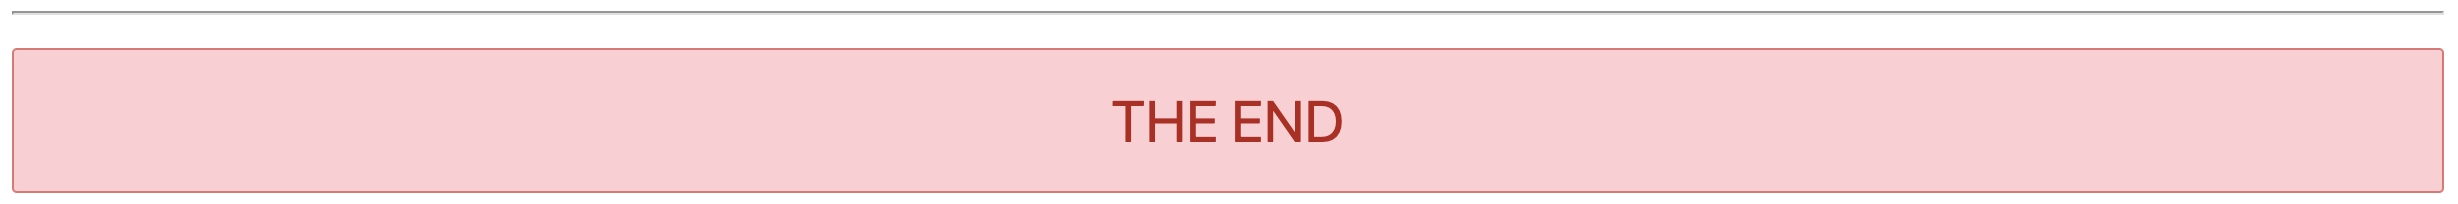